<a href="https://colab.research.google.com/github/Miguel68556/gun-death-intent-rf/blob/main/Math_457_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Necessary Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, average_precision_score, precision_recall_curve, auc, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

#Load Data

In [ ]:
gd = pd.read_csv('https://raw.githubusercontent.com/fivethirtyeight/guns-data/refs/heads/master/full_data.csv')

In [ ]:
gd_clean = gd.drop(['Unnamed: 0', 'hispanic'], axis = 1)
gd_clean = gd_clean.dropna()
gd_clean

,year,month,intent,police,sex,age,race,place,education
0,2012,1,Suicide,0,M,34.0,Asian/Pacific Islander,Home,BA+
1,2012,1,Suicide,0,F,21.0,White,Street,Some college
2,2012,1,Suicide,0,M,60.0,White,Other specified,BA+
3,2012,2,Suicide,0,M,64.0,White,Home,BA+
4,2012,2,Suicide,0,M,31.0,White,Other specified,HS/GED
...,...,...,...,...,...,...,...,...,...
100793,2014,12,Homicide,0,M,36.0,Black,Home,HS/GED
100794,2014,12,Homicide,0,M,19.0,Black,Street,HS/GED
100795,2014,12,Homicide,0,M,20.0,Black,Street,HS/GED
100796,2014,12,Homicide,0,M,22.0,Hispanic,Street,Less than HS


We dropped Unamed : 0 because it was just an index column and we also dropped hispanic columns as it didn't add anything to the model and we didn't know what the vlaues meant.

#Exploratory Data Analysis

What is the reason (intent) for most of the gun deaths?

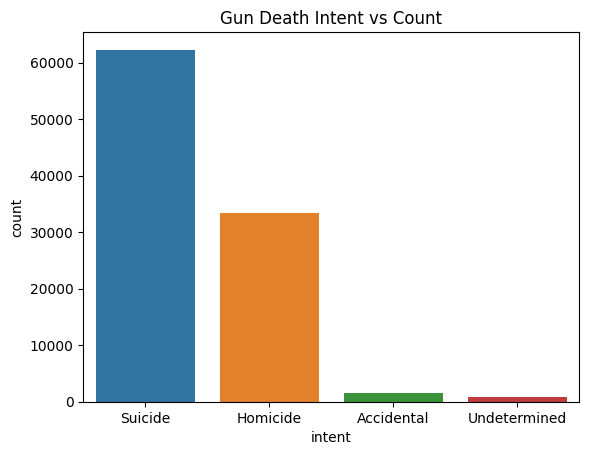

In [ ]:
graph = gd_clean['intent'].value_counts()
graph = graph.reset_index()
sns.barplot(graph, x = "intent", y = 'count', hue = 'intent', legend = False)
plt.title("Gun Death Intent vs Count")
plt.show()

We can see that suicide and homicide make up most of the gun deaths, with suicide being the leader. However, accidental and undetermined are very unrepresentative, as they make up approximaltey 2% of the data.

Lets examine how some of the features would affect the intent.

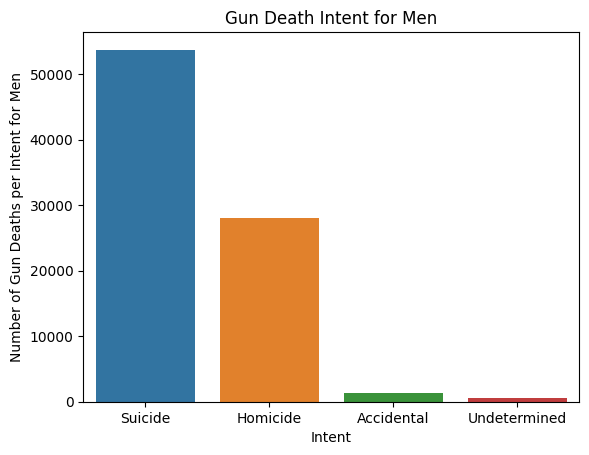

In [ ]:
#Sex

data = gd_clean.loc[gd_clean.sex == "M"]
dataf = gd_clean.loc[gd_clean.sex == "F"]

graph2 = data["intent"].value_counts()
graph2f = dataf["intent"].value_counts()
graph2 = graph2.reset_index()
graph2f = graph2f.reset_index()


sns.barplot(graph2, x = 'intent', y = 'count', hue = 'intent', legend = False)
plt.title("Gun Death Intent for Men")
plt.ylabel('Number of Gun Deaths per Intent for Men')
plt.xlabel("Intent")
plt.show()

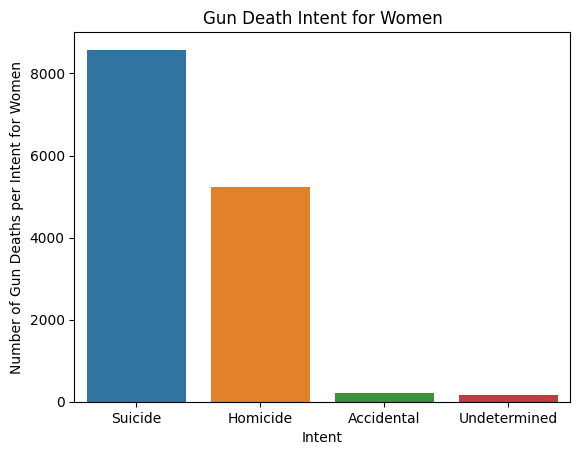

In [ ]:
sns.barplot(graph2f, x = 'intent', y = 'count', hue = 'intent', legend = False)
plt.title("Gun Death Intent for Women")
plt.ylabel('Number of Gun Deaths per Intent for Women')
plt.xlabel("Intent")
plt.show()

Suicide causes the most deaths among each gender

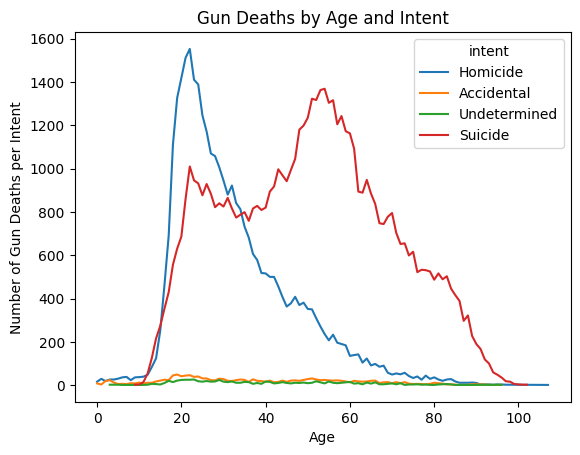

In [ ]:
#Age

data_age = gd_clean.groupby('age')['intent'].value_counts()
data_age = data_age.reset_index()

sns.lineplot(data_age, x = "age", y = "count", hue = 'intent')
plt.xlabel('Age')
plt.ylabel('Number of Gun Deaths per Intent')
plt.title('Gun Deaths by Age and Intent')
plt.show()

We can see the homicides spike when people are younger (around 20) while suicide are more popular when a bit older (around 50-60)

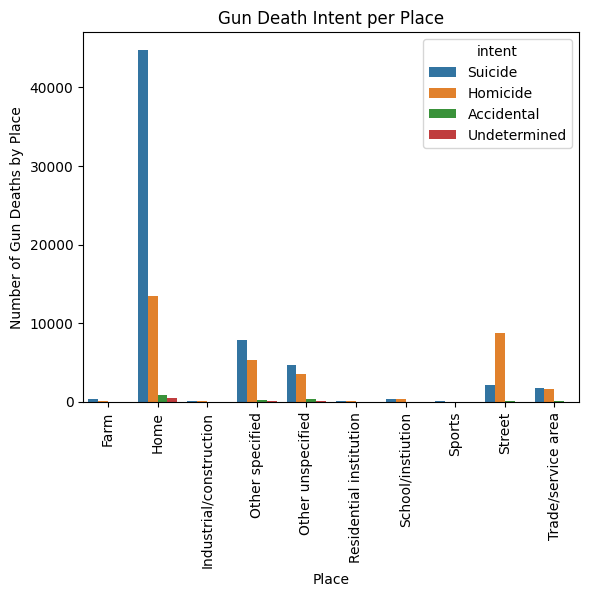

In [ ]:
#Place

data_place = gd_clean.groupby('place')['intent'].value_counts()
data_place = data_place.reset_index()

sns.barplot(data_place, x = 'place', y = 'count', hue = 'intent')
plt.title("Gun Death Intent per Place")
plt.xlabel("Place")
plt.ylabel("Number of Gun Deaths by Place")
plt.xticks(rotation = 90)
plt.show()

Gun deaths are very likley to happen at home, particularly suicides.A decent amount of the homicides happen in the street.

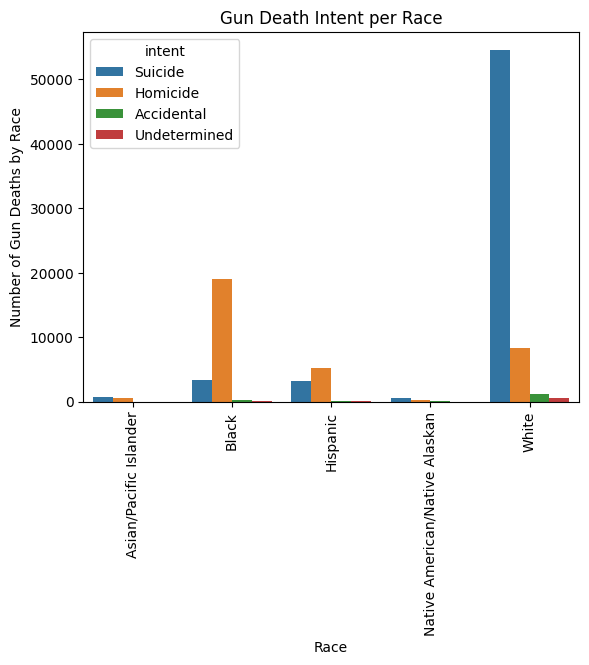

In [ ]:
#Race
data_race = gd_clean.groupby('race')['intent'].value_counts()
data_race = data_race.reset_index()

sns.barplot(data_race, x = 'race', y = 'count', hue = 'intent')
plt.title("Gun Death Intent per Race")
plt.xlabel("Race")
plt.ylabel("Number of Gun Deaths by Race")
plt.xticks(rotation = 90)
plt.show()

Gun deaths are most common among white and black people, also important to note that they are the most represented in this dataset. We see sucide is more prevalent among white people while homicide is more prevelant among black people.

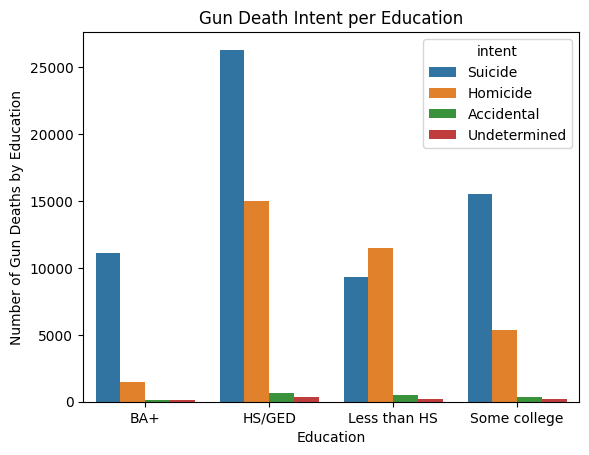

In [ ]:
# Education

data_ed = gd_clean.groupby('education')['intent'].value_counts()
data_ed = data_ed.reset_index()

sns.barplot(data_ed, x = 'education', y = 'count', hue = 'intent')
plt.title("Gun Death Intent per Education")
plt.xlabel("Education")
plt.ylabel("Number of Gun Deaths by Education")
plt.show()

Suicide is the most common for all levels of education except less than high school, where homicide is more commons. Suicide levels are very high in HS/GED education level

#Predictive Modeling

Can we predict the intent of a gun death by all the other features?

In [ ]:
gd_clean.columns

Index(['year', 'month', 'intent', 'police', 'sex', 'age', 'race', 'place',
       'education'],
      dtype='object')

In [ ]:
y = gd_clean['intent']
X = gd_clean.drop(['intent'], axis = 1)

X = pd.get_dummies(X,drop_first=True)
feature_names = X.columns.tolist()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=67, stratify = y)

Best accuracy: 0.8321 at max_depth = 12


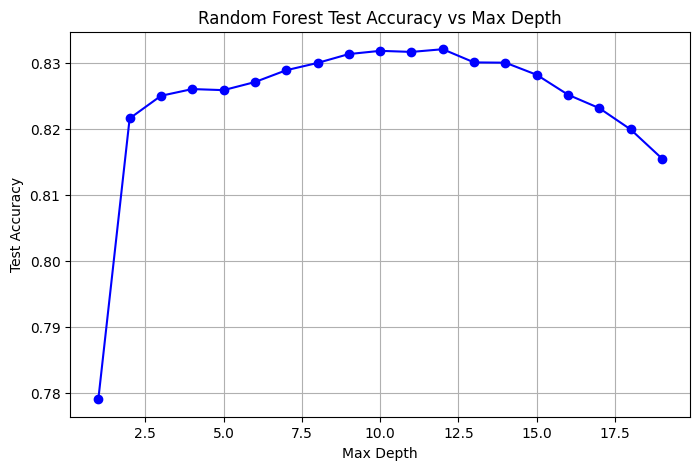

In [ ]:
test_list = []

for x in range(1,20,1):
  model = RandomForestClassifier(max_depth = x, random_state = 67).fit(X_train, y_train)
  yhat_train = model.predict(X_train)
  yhat_test = model.predict(X_test)
  test = accuracy_score(yhat_test, y_test)
  test_list.append(test)

best_acc = max(test_list)
best_depth = range(1, 20)[test_list.index(best_acc)]

print(f"Best accuracy: {best_acc:.4f} at max_depth = {best_depth}")

plt.figure(figsize=(8,5))
plt.plot(range(1, 20), test_list, marker='o', linestyle='-', color='blue')
plt.xlabel('Max Depth')
plt.ylabel('Test Accuracy')
plt.title('Random Forest Test Accuracy vs Max Depth')
plt.grid(True)

Here we wanted to find with max depth would achieve the highest accuracy. When there was no max depth, the accuracy was 0.79 and when We ran this, we found that when max depth = 12, the test accuracy is at a max at 0.83

In [ ]:
model = RandomForestClassifier(max_depth = 12, random_state= 67).fit(X_train, y_train)

In [ ]:
yhat_train = model.predict(X_train)
yhat_test = model.predict(X_test)

print(f"Train Accuracy: {accuracy_score(yhat_train, y_train):.2f}")
print(f"Test Accuracy:  {accuracy_score(yhat_test, y_test):.2f}")
print(f"Null Accuracy:  {y_test.value_counts(normalize=True).iloc[0]:.2f}")

Train Accuracy: 0.85
Test Accuracy:  0.83
Null Accuracy:  0.64


In [ ]:
cv_score = cross_val_score(model, X, y, cv = 5, scoring = "accuracy")
print(cv_score.mean(), cv_score.std())

0.8302912819466408 0.007168343133934566


Our model generalizes well, as it seems properly fit with train accuracy of 0.85 and test accuracy of 0.83. We also see that our model is is 0.19 better than null accuracy. This is very good as our model is a lot better than just randomly guessing.

In [ ]:
print(classification_report(y_test, yhat_test))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

  Accidental       0.55      0.01      0.03       400
    Homicide       0.82      0.72      0.76      8332
     Suicide       0.84      0.92      0.88     15573
Undetermined       0.00      0.00      0.00       199

    accuracy                           0.83     24504
   macro avg       0.55      0.41      0.42     24504
weighted avg       0.82      0.83      0.82     24504



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


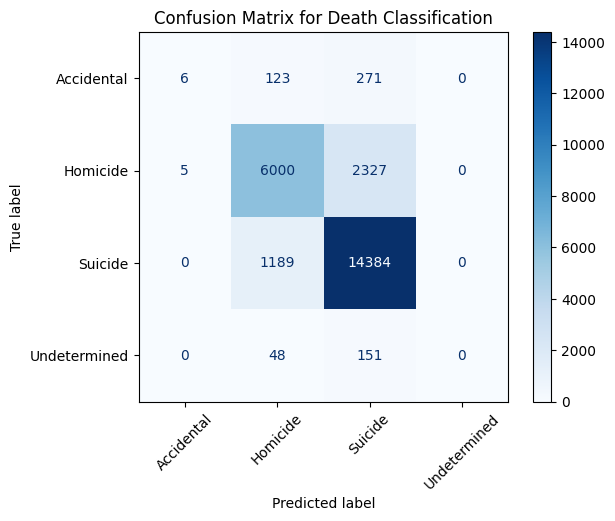

In [ ]:
confusion = confusion_matrix(y_test, yhat_test)

labels = ["Accidental", "Homicide", "Suicide", "Undetermined"]

disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for Death Classification")
plt.xticks(rotation=45)
plt.show()

In [ ]:
y.value_counts(normalize = True)

,proportion
intent,
Suicide,0.635525
Homicide,0.340040
Accidental,0.016304
Undetermined,0.008131


We can see from the confusion matrix tand classification report that our model predicts suicide and homicide well, but struggles when it comes to accidental and undetermined. This is expected however since accidental makes up 1.6% of the data and undetermined makes up 0.8% of the data, so it would be near impossible for them to have any predicitive power in this model.

In [ ]:
classes = ['Accidental','Homicide','Suicide','Undetermined']
y_test_bin = label_binarize(y_test, classes=['Accidental','Homicide','Suicide','Undetermined'])

y_proba = model.predict_proba(X_test)

pr_auc_per_class = {}
for i in range(4):
  precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
  pr_auc = auc(recall, precision)
  pr_auc_per_class[f"class_{i}"] = print(pr_auc)

macro_ap = average_precision_score(y_test_bin, y_proba, average = 'macro')
micro_ap = average_precision_score(y_test_bin, y_proba, average = 'micro')

print("Per-class PR AUC:", pr_auc_per_class)
print("Macro-average PR AUC:", macro_ap)
print("Micro-average PR AUC:", micro_ap)

0.06324033606907953
0.8371750921771522
0.915461215030991
0.011512339247186103
Per-class PR AUC: {'class_0': None, 'class_1': None, 'class_2': None, 'class_3': None}
Macro-average PR AUC: 0.45719795738217367
Micro-average PR AUC: 0.8813037071946692


In [ ]:
roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
print(f"ROC AUC (multi-class): {roc_auc:.4f}")

ROC AUC (multi-class): 0.7633


We found the PR AUC per class and found consistent results with classification reports. The homicide and suicidal PR AUC were very good, while accidental and undetermined were very poor, but again it is expected as they are very underepresented. The macro and micro averages just prove this. We also had an ROC AUC of 0.7633 which is pretty good, but is being dragged down by accident and undetermined

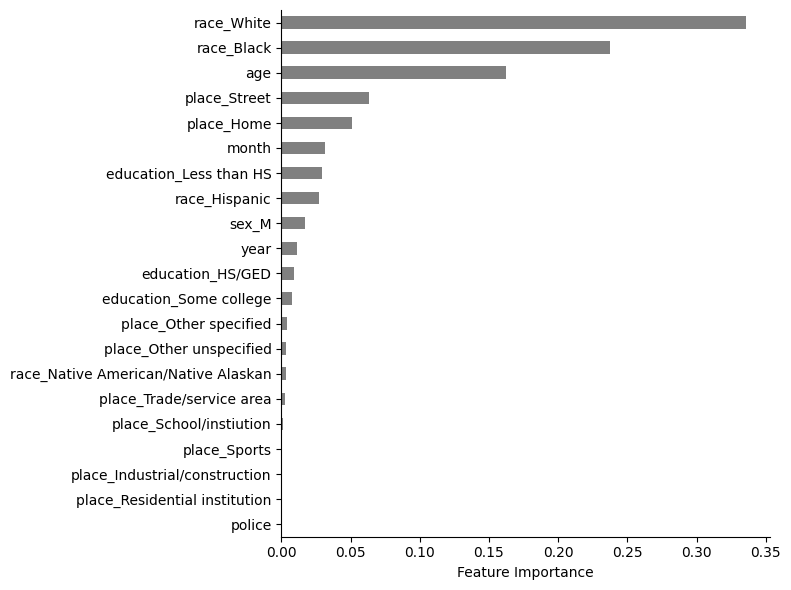

In [ ]:
importances = model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Gini Importance': importances
})
feature_imp_df = feature_imp_df.sort_values('Gini Importance', ascending=False)

forest_importances = pd.Series(model.feature_importances_,index=feature_names)
forest_importances.sort_values(inplace=True, ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
forest_importances.plot.barh(ax=ax, color='grey')
ax.set_xlabel("Feature Importance")


ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

fig.tight_layout()

These are the most important features.

#New Model

Since Accidental and Undetermined are negligible, what if we only trained on suicide and homicide.

In [ ]:
newdata = gd_clean.loc[(gd_clean.intent == "Suicide") | (gd_clean.intent == 'Homicide')]
newdata

,year,month,intent,police,sex,age,race,place,education
0,2012,1,Suicide,0,M,34.0,Asian/Pacific Islander,Home,BA+
1,2012,1,Suicide,0,F,21.0,White,Street,Some college
2,2012,1,Suicide,0,M,60.0,White,Other specified,BA+
3,2012,2,Suicide,0,M,64.0,White,Home,BA+
4,2012,2,Suicide,0,M,31.0,White,Other specified,HS/GED
...,...,...,...,...,...,...,...,...,...
100793,2014,12,Homicide,0,M,36.0,Black,Home,HS/GED
100794,2014,12,Homicide,0,M,19.0,Black,Street,HS/GED
100795,2014,12,Homicide,0,M,20.0,Black,Street,HS/GED
100796,2014,12,Homicide,0,M,22.0,Hispanic,Street,Less than HS


In [ ]:
y2 = newdata['intent']
X2 = newdata.drop(['intent'], axis = 1)

X2 = pd.get_dummies(X2,drop_first=True)
feature_names2 = X2.columns.tolist()

In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, random_state=67, stratify = y2)

Best accuracy: 0.8535 at max_depth = 11


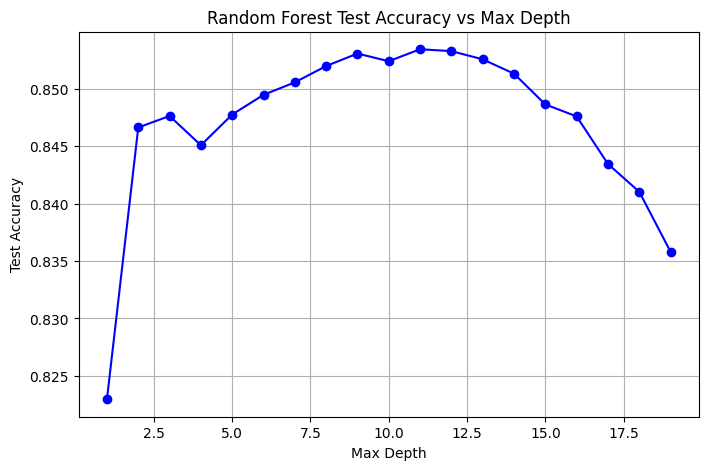

In [ ]:
test_list = []

for x in range(1,20,1):
  model = RandomForestClassifier(max_depth = x).fit(X2_train, y2_train)
  yhat_train = model.predict(X2_train)
  yhat_test = model.predict(X2_test)
  test = accuracy_score(yhat_test, y2_test)
  test_list.append(test)

best_acc2 = max(test_list)
best_depth2 = range(1, 20)[test_list.index(best_acc2)]

print(f"Best accuracy: {best_acc2:.4f} at max_depth = {best_depth2}")

plt.figure(figsize=(8,5))
plt.plot(range(1, 20), test_list, marker='o', linestyle='-', color='blue')  # line + points
plt.xlabel('Max Depth')
plt.ylabel('Test Accuracy')
plt.title('Random Forest Test Accuracy vs Max Depth')
plt.grid(True)

In [ ]:
model2 = RandomForestClassifier(max_depth = 11, random_state= 67).fit(X2_train, y2_train)

In [ ]:
yhat_train2 = model2.predict(X2_train)
yhat_test2 = model2.predict(X2_test)

print(f"Train Accuracy: {accuracy_score(yhat_train2, y2_train):.2f}")
print(f"Test Accuracy:  {accuracy_score(yhat_test2, y2_test):.2f}")
print(f"Null Accuracy:  {y2_test.value_counts(normalize=True).iloc[0]:.2f}")

Train Accuracy: 0.86
Test Accuracy:  0.85
Null Accuracy:  0.65


In [ ]:
cv_score2 = cross_val_score(model2, X2, y2, cv = 5, scoring = "accuracy")
print(cv_score2.mean(), cv_score2.std())

0.8517674126751725 0.007872733817144038


In [ ]:
print(classification_report(y2_test, yhat_test2))

              precision    recall  f1-score   support

    Homicide       0.84      0.72      0.77      8332
     Suicide       0.86      0.93      0.89     15573

    accuracy                           0.85     23905
   macro avg       0.85      0.82      0.83     23905
weighted avg       0.85      0.85      0.85     23905



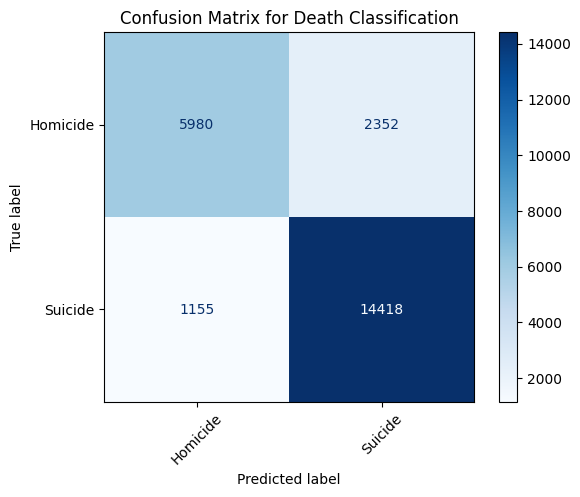

In [ ]:
confusion = confusion_matrix(y2_test, yhat_test2)

labels = ["Homicide", "Suicide"]

disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for Death Classification")
plt.xticks(rotation=45)
plt.show()

In [ ]:
y_test_encoded = y2_test.map({'Homicide': 0, 'Suicide': 1})

y_proba = model.predict_proba(X2_test)[:, 1]

roc_auc = roc_auc_score(y_test_encoded, y_proba)
print(f"ROC AUC = {roc_auc:.4f}")

pr_auc = average_precision_score(y_test_encoded, y_proba)
print(f"PR-AUC = {pr_auc:.3f}")

ROC AUC = 0.8797
PR-AUC = 0.919


This model is ever so slightly better than the previous, but basically the same. This one has a better ROC and PR AUC than the previous model. Both models will suffice, but model without Accidental and Undetermined performs better

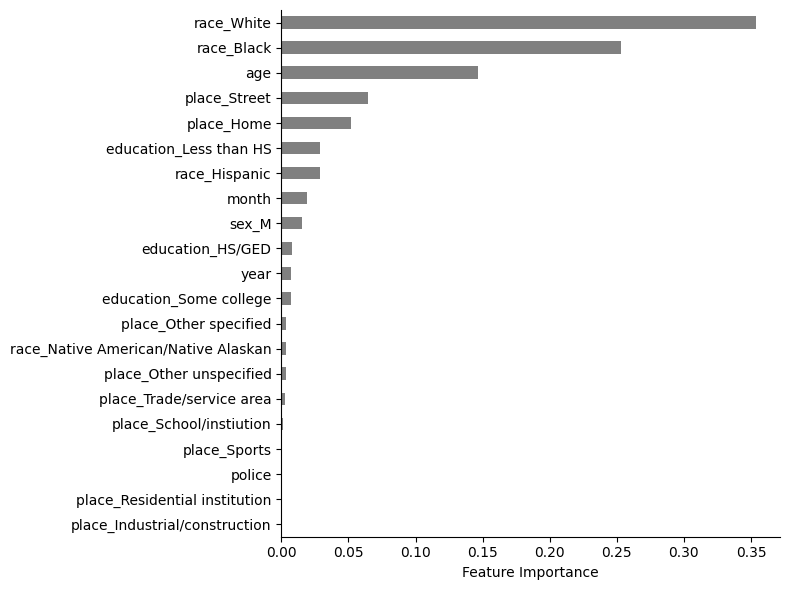

In [ ]:
importances = model2.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': feature_names2,
    'Gini Importance': importances
})
feature_imp_df = feature_imp_df.sort_values('Gini Importance', ascending=False)

forest_importances = pd.Series(model2.feature_importances_,index=feature_names)
forest_importances.sort_values(inplace=True, ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
forest_importances.plot.barh(ax=ax, color='grey')
ax.set_xlabel("Feature Importance")


ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

fig.tight_layout()

Same important features as last time. Elaborate in paper on how this makes sense with our findings in EDA section.